In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
df['City'].unique()


<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

In [3]:
bhopal = df[df['City'] == 'Bhopal'].copy()
print(f"Final rows after preprocessing: {len(bhopal)}")
bhopal.head()

Rows for Bhopal: 289


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
6303,Bhopal,2019-09-17,23.12,43.95,13.38,38.58,31.40,34.63,1.52,10.53,41.86,NaN,NaN,NaN,NaN,NaN
6304,Bhopal,2019-09-18,21.25,38.20,16.08,37.81,33.18,44.14,1.38,8.95,24.70,NaN,NaN,NaN,89.0,Satisfactory
6305,Bhopal,2019-09-19,16.94,41.09,12.94,25.28,23.96,47.43,0.95,8.08,31.66,NaN,NaN,NaN,77.0,Satisfactory
6306,Bhopal,2019-09-20,15.29,43.10,11.93,26.05,23.56,42.29,0.95,7.52,30.93,NaN,NaN,NaN,76.0,Satisfactory
6307,Bhopal,2019-09-21,20.75,62.70,14.90,30.90,28.55,46.25,1.41,7.31,27.19,NaN,NaN,NaN,82.0,Satisfactory


In [4]:
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal = bhopal.sort_values('Date')
bhopal.isnull().sum()

City            0
Date            0
PM2.5           9
PM10            9
NO              9
NO2             9
NOx             9
NH3             9
CO              9
SO2             9
O3              9
Benzene       289
Toluene       289
Xylene        289
AQI            11
AQI_Bucket     11
dtype: int64

In [8]:
print(bhopal.columns.tolist())


['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket']


In [9]:
import pandas as pd
bhopal['Date'] = pd.to_datetime(bhopal['Date'])
bhopal.sort_values('Date', inplace=True)
bhopal = bhopal.dropna(subset=['AQI'])
bhopal.ffill(inplace=True)
for lag in [1, 2, 3, 7]:
    bhopal[f'AQI_lag_{lag}'] = bhopal['AQI'].shift(lag)
bhopal.dropna(inplace=True)

print(f"Rows after cleaning: {len(bhopal)}")

Rows after cleaning: 271


Features used: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_3', 'AQI_lag_7']
X shape: (271, 13)
y shape: (271,)
Train samples: 216, Test samples: 55
MAE: 19.72
R²: -0.07


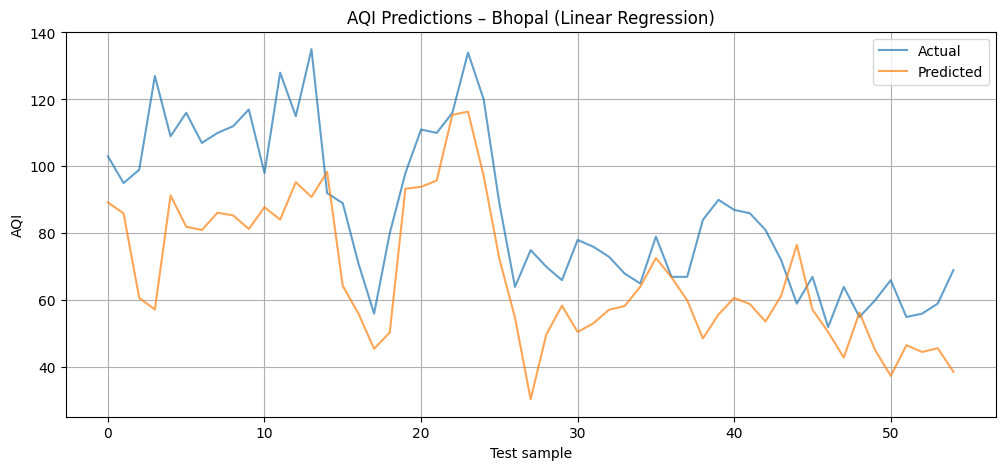

In [10]:
# Columns to exclude (not features)
exclude = ['Date', 'City', 'AQI', 'AQI_Bucket']
feature_cols = [c for c in bhopal.columns if c not in exclude]
X = bhopal[feature_cols]
y = bhopal['AQI']

print("Features used:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('AQI Predictions – Bhopal (Linear Regression)')
plt.xlabel('Test sample')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show() 

MAE (Random Forest): 8.47
R² (Random Forest): 0.74


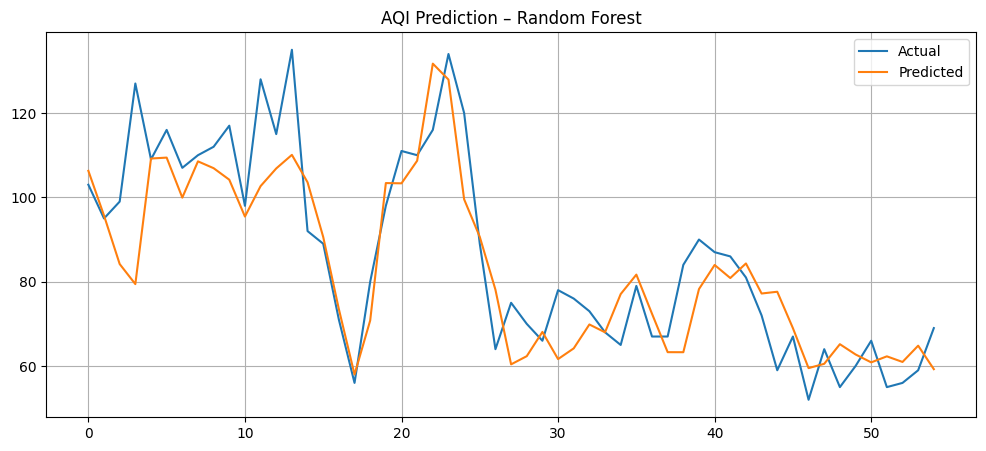

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Random Forest): {mae:.2f}")
print(f"R² (Random Forest): {r2:.2f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title('AQI Prediction – Random Forest')
plt.legend()
plt.grid()

plt.show()